Attributing Star Luminosities

In [244]:
import numpy as np
import os
import yt
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt 
import pandas as pd

In [317]:
pop_2_data = np.loadtxt(r"star_positions_out400.txt") 
ages = pop_2_data[:,0] # myr
x_pos = pop_2_data[:,1]
y_pos = pop_2_data[:,2] 
xlim = -125, 125
ylim = -125, 125

### Just doing raw counts

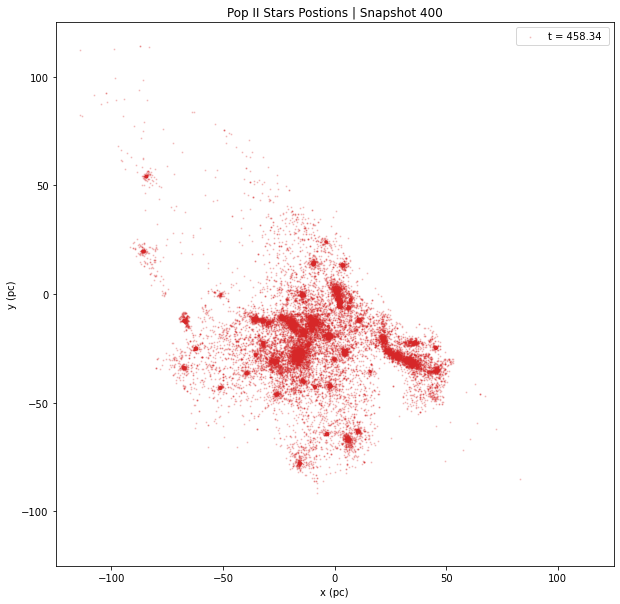

In [79]:
plt.figure(figsize = (10,10)) 

plt.scatter(x_pos, y_pos, s=1, c='tab:red', alpha=.2, label='t = 458.34 ')
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("Pop II Stars Postions | Snapshot 400")
plt.xlabel("x (pc)")
plt.ylabel("y (pc)")
plt.legend()

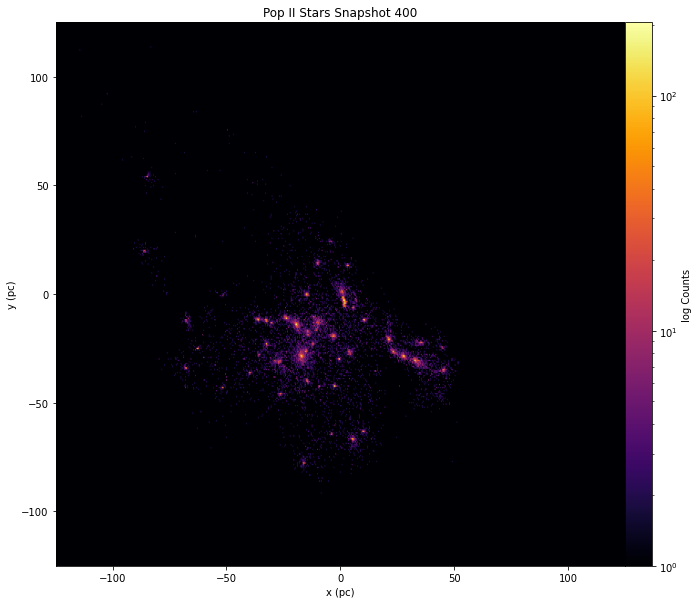

In [108]:
plt.figure(figsize = (12,10), )
log_scale = plt.hexbin(x_pos, y_pos, gridsize=1000, cmap='inferno', bins='log', extent=[-200, 200, -200, 200])
plt.xlim(-125, 125)
plt.ylim(-125, 125)
plt.title("Pop II Stars Snapshot 400")
plt.xlabel("x (pc)")
plt.ylabel("y (pc)")
plt.colorbar(log_scale, label='log Counts', pad = 0)

In [123]:
pixel_values = log_scale.get_array() 
positons = log_scale.get_offsets() 
x = positons[:,0]
y = positons[:,1]

(-125.0, 125.0)

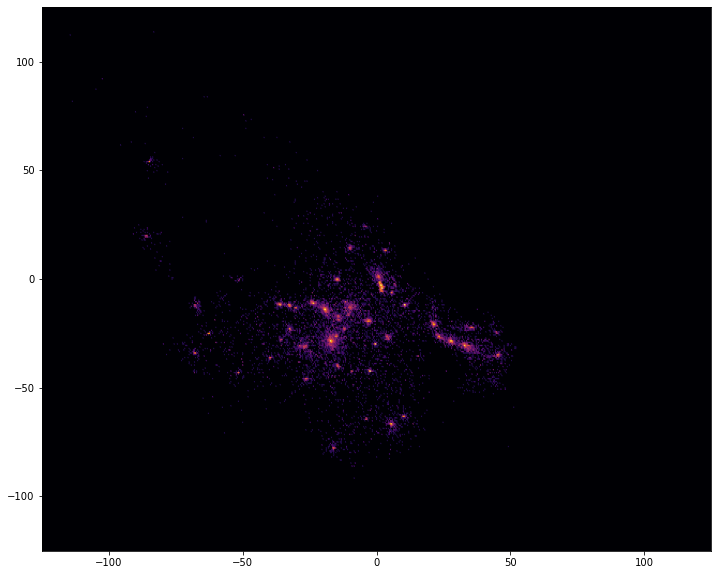

In [124]:
plt.figure(figsize = (12,10), )
plt.hexbin(x , y, pixel_values, cmap='inferno', bins='log', gridsize=1000)
plt.xlim(-125, 125)
plt.ylim(-125, 125)

In [128]:
print(pixel_values.min())

1.0


In [308]:
df = pd.read_csv('https://www.stsci.edu/science/starburst99/data/l1500_inst_e.dat', delim_whitespace=True, header=None)
data = df.to_numpy().astype(float)
time = data[:,0]
lum = data[:,2] 

In [309]:
def power_law(time, a, exp):
    lum = a * time**exp
    return lum

[ 4.56523421e+01 -1.06687202e-02]


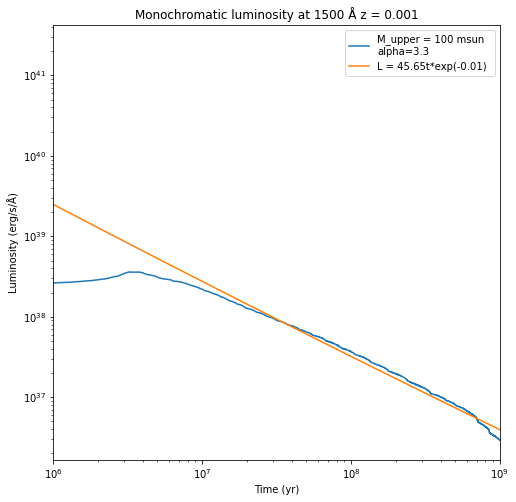

In [316]:
plt.figure(figsize = (8,8), )
plt.plot(time, 10**lum, label='M_upper = 100 msun  \nalpha=3.3')
mask = time > 6.5e6
par, cov = curve_fit(power_law, time, lum) 
plt.plot(time, 10**power_law(time, *par), label = r'L = {:.2f}t*exp({:.2f})'.format(par[0], par[1]))

print(par)
plt.xlim(1e6,1e9)
plt.xscale('log')
plt.yscale('log')
plt.title("Monochromatic luminosity at 1500 Å z = 0.001")
plt.xlabel("Time (yr)")
plt.ylabel("Luminosity (erg/s/Å)")
plt.legend()

In [318]:
staller_lum = power_law(ages, )

[567.405099   567.405099   567.405099   ... 493.95069943 493.95069943
 493.95069943]


In [319]:
#print(np.min(ages))

458.3417399090517
